# Cyclic (irregular cycles)

Cyclic series oscillate, but — unlike a clean seasonal wave — with *irregular* periods and amplitudes: business cycles, ecological booms and busts, quasi-periodic signals. The generator overlays one or more noisy cycles so the period drifts rather than repeating exactly.

::: {.callout-note}
## The model

$$y_t = \text{base} + \text{trend}\cdot t + \sum_{i=1}^{n} A_i \sin\!\big(\psi_i(t)\big) + \varepsilon_t$$

Each series superimposes `num_cycles` oscillations whose periods vary from cycle to cycle (`cycle_period_std` controls how irregular). Small variance approaches a fixed seasonal wave; large variance produces genuinely aperiodic cycling.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import CyclicGenerator

## 1. Basic business cycle

A simple model with ~60-day cycles, upward trend, and 3 overlapping cycle components.

In [ ]:
basic_params = {
    "min_length": 300,
    "max_length": 300,
    "freq": "D",
    "base_level": 100.0,
    "trend": 0.05,
    "cycle_period_mean": 60.0,
    "cycle_amplitude_mean": 20.0,
    "num_cycles": 3,
    "seed": 42,
}

basic_gen = CyclicGenerator(engine="polars", **basic_params)
basic_df = basic_gen.generate(n_series=1)

print(f"Generated {len(basic_df)} observations with irregular cycles")
print(f"Statistics: Mean={basic_df['y'].mean():.4f}, Std={basic_df['y'].std():.4f}")
basic_df.head(10)

Generated 300 observations with irregular cycles
Statistics: Mean=105.2939, Std=25.9592


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,93.663885
"""0""",2000-01-02 00:00:00,92.69384
"""0""",2000-01-03 00:00:00,88.046548
"""0""",2000-01-04 00:00:00,86.119544
"""0""",2000-01-05 00:00:00,85.275164
"""0""",2000-01-06 00:00:00,80.548824
"""0""",2000-01-07 00:00:00,79.348091
"""0""",2000-01-08 00:00:00,79.021414
"""0""",2000-01-09 00:00:00,79.888552


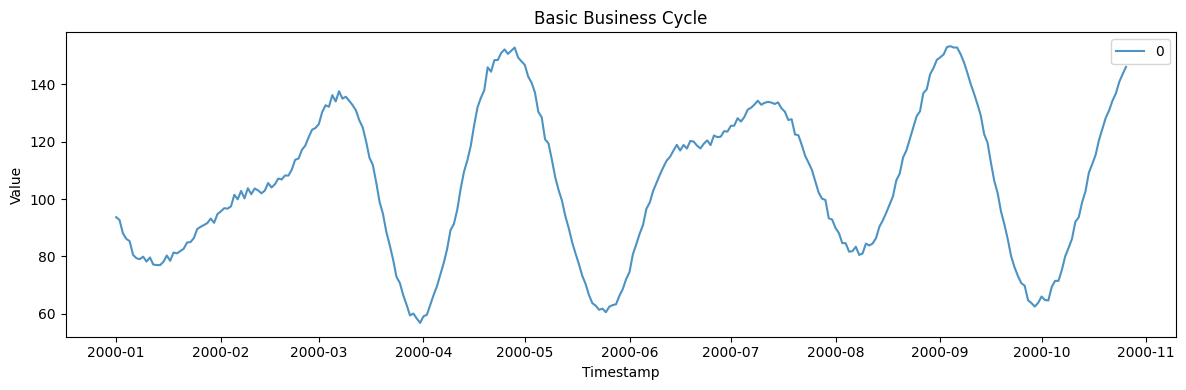

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in basic_df["unique_id"].unique().to_list():
    series = basic_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Basic Business Cycle")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Fast cycles (monthly patterns)

Shorter ~30-day cycles with 5 overlapping components.

In [ ]:
fast_params = {
    "min_length": 400,
    "max_length": 400,
    "freq": "D",
    "base_level": 50.0,
    "trend": 0.02,
    "cycle_period_mean": 30.0,
    "cycle_amplitude_mean": 10.0,
    "num_cycles": 5,
    "seed": 42,
}

fast_gen = CyclicGenerator(engine="polars", **fast_params)
fast_df = fast_gen.generate(n_series=1)

print(f"Generated {len(fast_df)} observations with fast cycles")
print(f"Statistics: Mean={fast_df['y'].mean():.4f}, Std={fast_df['y'].std():.4f}")
fast_df.head(10)

Generated 400 observations with fast cycles
Statistics: Mean=53.2412, Std=28.5389


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,72.909227
"""0""",2000-01-02 00:00:00,74.747078
"""0""",2000-01-03 00:00:00,77.028095
"""0""",2000-01-04 00:00:00,75.842216
"""0""",2000-01-05 00:00:00,76.859084
"""0""",2000-01-06 00:00:00,72.885358
"""0""",2000-01-07 00:00:00,70.139578
"""0""",2000-01-08 00:00:00,66.440151
"""0""",2000-01-09 00:00:00,62.914334


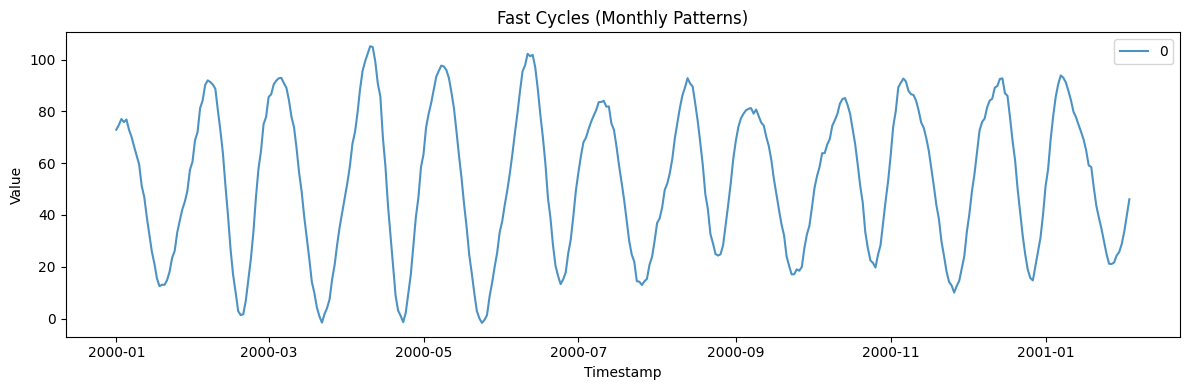

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in fast_df["unique_id"].unique().to_list():
    series = fast_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Fast Cycles (Monthly Patterns)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Slow cycles (quarterly patterns)

Longer ~90-day cycles with high amplitude, simulating quarterly business cycles.

In [ ]:
slow_params = {
    "min_length": 500,
    "max_length": 500,
    "freq": "D",
    "base_level": 100.0,
    "trend": 0.03,
    "cycle_period_mean": 90.0,
    "cycle_amplitude_mean": 30.0,
    "num_cycles": 2,
    "seed": 42,
}

slow_gen = CyclicGenerator(engine="polars", **slow_params)
slow_df = slow_gen.generate(n_series=1)

print(f"Generated {len(slow_df)} observations with slow cycles")
print(f"Statistics: Mean={slow_df['y'].mean():.4f}, Std={slow_df['y'].std():.4f}")
slow_df.head(10)

Generated 500 observations with slow cycles
Statistics: Mean=107.5731, Std=25.5262


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.289452
"""0""",2000-01-02 00:00:00,98.00997
"""0""",2000-01-03 00:00:00,97.255182
"""0""",2000-01-04 00:00:00,96.080102
"""0""",2000-01-05 00:00:00,96.742441
"""0""",2000-01-06 00:00:00,93.572466
"""0""",2000-01-07 00:00:00,92.956132
"""0""",2000-01-08 00:00:00,93.248319
"""0""",2000-01-09 00:00:00,89.48066


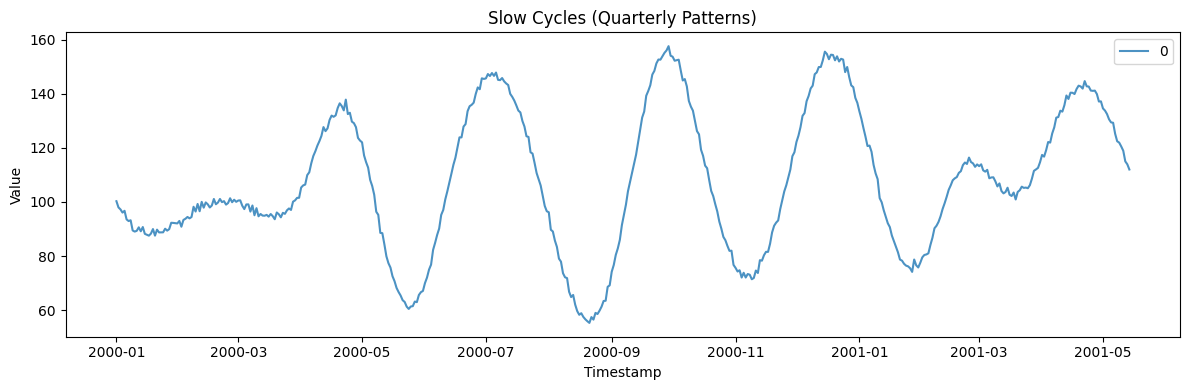

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in slow_df["unique_id"].unique().to_list():
    series = slow_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Slow Cycles (Quarterly Patterns)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. High amplitude cycles (large fluctuations)

An amplitude of 50 produces large swings around the base level.

In [ ]:
high_amp_params = {
    "min_length": 300,
    "max_length": 300,
    "freq": "D",
    "base_level": 100.0,
    "trend": 0.01,
    "cycle_period_mean": 60.0,
    "cycle_amplitude_mean": 50.0,
    "num_cycles": 3,
    "seed": 42,
}

high_amp_gen = CyclicGenerator(engine="polars", **high_amp_params)
high_amp_df = high_amp_gen.generate(n_series=1)

print(f"Generated {len(high_amp_df)} observations with high amplitude cycles")
print(f"Statistics: Mean={high_amp_df['y'].mean():.4f}, Std={high_amp_df['y'].std():.4f}")
high_amp_df.head(10)

Generated 300 observations with high amplitude cycles
Statistics: Mean=95.7914, Std=69.8237


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,79.572658
"""0""",2000-01-02 00:00:00,73.834076
"""0""",2000-01-03 00:00:00,64.882192
"""0""",2000-01-04 00:00:00,59.134291
"""0""",2000-01-05 00:00:00,54.963447
"""0""",2000-01-06 00:00:00,47.407805
"""0""",2000-01-07 00:00:00,43.870643
"""0""",2000-01-08 00:00:00,41.690049
"""0""",2000-01-09 00:00:00,41.170252


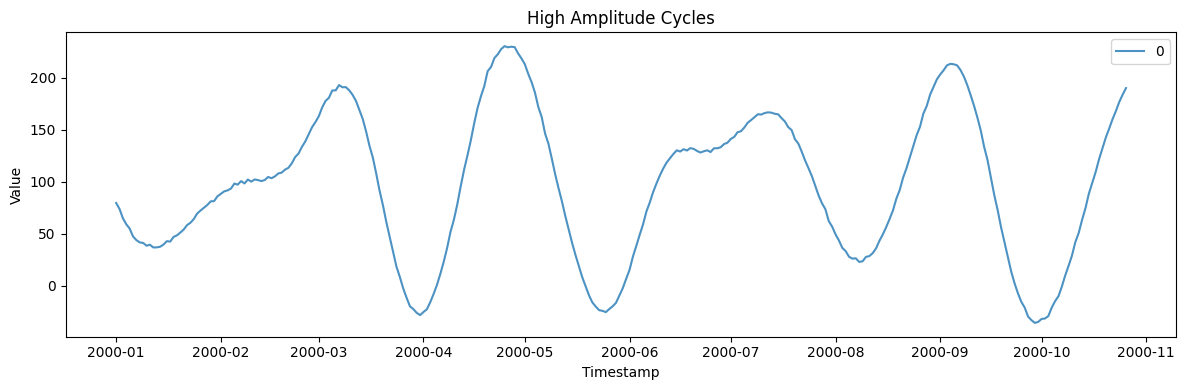

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in high_amp_df["unique_id"].unique().to_list():
    series = high_amp_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("High Amplitude Cycles")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Negative trend with cycles (declining market)

A downward trend combined with cyclical fluctuations.

In [ ]:
declining_params = {
    "min_length": 300,
    "max_length": 300,
    "freq": "D",
    "base_level": 150.0,
    "trend": -0.05,
    "cycle_period_mean": 50.0,
    "cycle_amplitude_mean": 20.0,
    "num_cycles": 3,
    "seed": 42,
}

declining_gen = CyclicGenerator(engine="polars", **declining_params)
declining_df = declining_gen.generate(n_series=1)

print(f"Generated {len(declining_df)} observations with declining trend")
print(f"Statistics: Mean={declining_df['y'].mean():.4f}, Std={declining_df['y'].std():.4f}")
declining_df.head(10)

Generated 300 observations with declining trend
Statistics: Mean=140.8307, Std=27.3867


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,143.101924
"""0""",2000-01-02 00:00:00,141.627292
"""0""",2000-01-03 00:00:00,136.638082
"""0""",2000-01-04 00:00:00,134.529648
"""0""",2000-01-05 00:00:00,133.656044
"""0""",2000-01-06 00:00:00,129.039617
"""0""",2000-01-07 00:00:00,128.071289
"""0""",2000-01-08 00:00:00,128.080343
"""0""",2000-01-09 00:00:00,129.365766


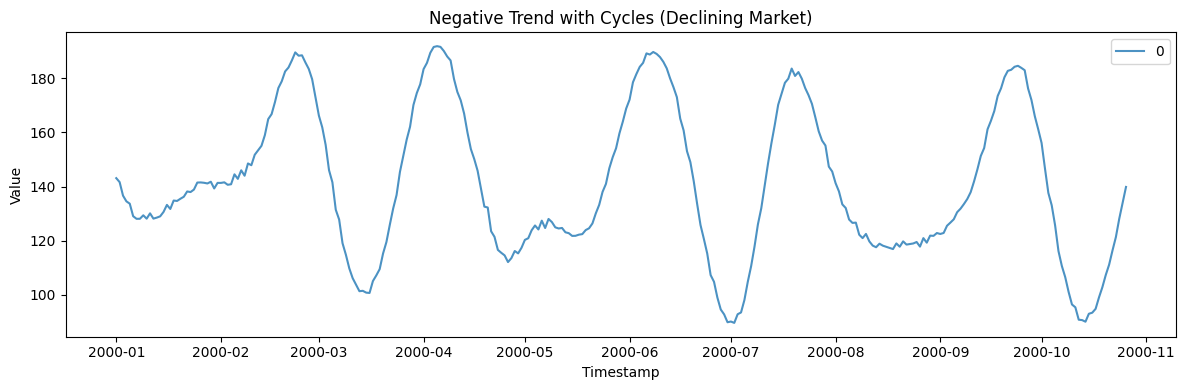

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in declining_df["unique_id"].unique().to_list():
    series = declining_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Negative Trend with Cycles (Declining Market)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Multiple overlapping cycles (complex pattern)

Five overlapping cycle components create a complex, realistic pattern.

In [ ]:
complex_params = {
    "min_length": 500,
    "max_length": 500,
    "freq": "D",
    "base_level": 100.0,
    "trend": 0.02,
    "cycle_period_mean": 60.0,
    "cycle_amplitude_mean": 15.0,
    "num_cycles": 5,
    "seed": 42,
}

complex_gen = CyclicGenerator(engine="polars", **complex_params)
complex_df = complex_gen.generate(n_series=1)

print(f"Generated {len(complex_df)} observations with multiple overlapping cycles")
print(f"Statistics: Mean={complex_df['y'].mean():.4f}, Std={complex_df['y'].std():.4f}")
complex_df.head(10)

Generated 500 observations with multiple overlapping cycles
Statistics: Mean=105.8392, Std=43.9463


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,126.751732
"""0""",2000-01-02 00:00:00,127.885824
"""0""",2000-01-03 00:00:00,129.749177
"""0""",2000-01-04 00:00:00,128.563635
"""0""",2000-01-05 00:00:00,130.119181
"""0""",2000-01-06 00:00:00,127.31363
"""0""",2000-01-07 00:00:00,126.418862
"""0""",2000-01-08 00:00:00,125.266044
"""0""",2000-01-09 00:00:00,124.954641


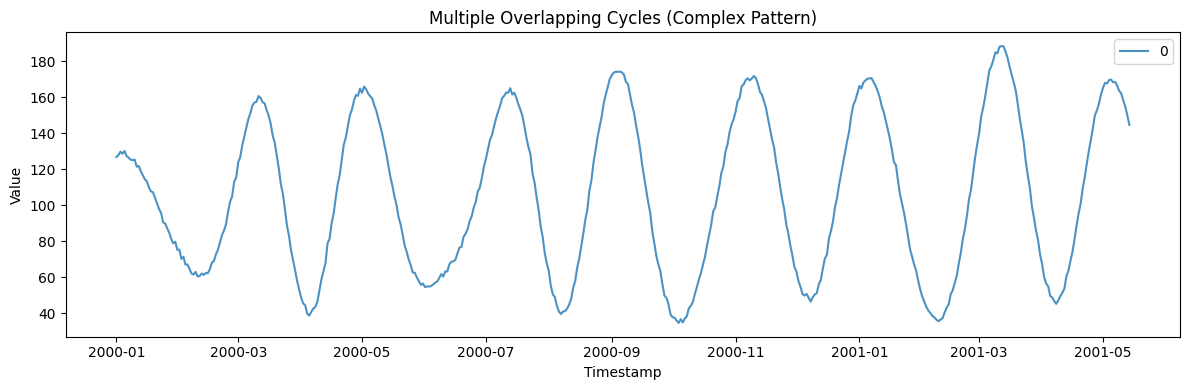

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in complex_df["unique_id"].unique().to_list():
    series = complex_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple Overlapping Cycles (Complex Pattern)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Multiple cyclic series

Generate multiple independent cyclic series in one call.

In [ ]:
multi_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "base_level": 100.0,
    "trend": 0.03,
    "cycle_period_mean": 60.0,
    "cycle_amplitude_mean": 20.0,
    "num_cycles": 3,
    "seed": 42,
}

multi_gen = CyclicGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=3)

print(f"Generated 3 series with {len(multi_df)} total observations")
print(f"Overall Statistics: Mean={multi_df['y'].mean():.4f}, Std={multi_df['y'].std():.4f}")
multi_df.filter(pl.col("unique_id") == "0").head(10)

Generated 3 series with 600 total observations
Overall Statistics: Mean=103.3095, Std=24.7829


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,93.663885
"""0""",2000-01-02 00:00:00,92.67384
"""0""",2000-01-03 00:00:00,88.006548
"""0""",2000-01-04 00:00:00,86.059544
"""0""",2000-01-05 00:00:00,85.195164
"""0""",2000-01-06 00:00:00,80.448824
"""0""",2000-01-07 00:00:00,79.228091
"""0""",2000-01-08 00:00:00,78.881414
"""0""",2000-01-09 00:00:00,79.728552


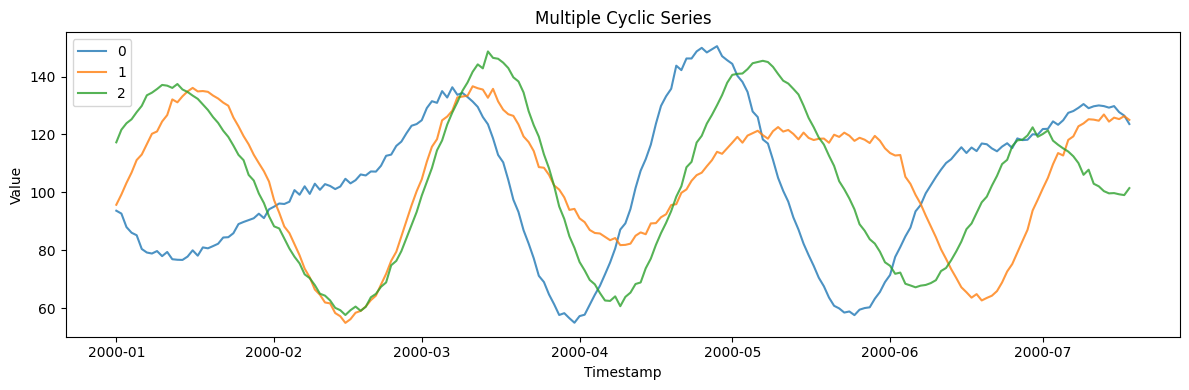

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple Cyclic Series")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Seasonal](../statistical/seasonal) — a fixed, exactly repeating period.
- [Gaussian process](../multivariate/gaussian_process) — periodic kernels for smooth quasi-periodicity.

Cycle-count and irregularity parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::